In [15]:
pip install gymnasium torch torchvision matplotlib numpy jupyter


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [16]:
pip install --upgrade pip

  Using cached pip-26.0.1-py3-none-any.whl.metadata (4.7 kB)
Using cached pip-26.0.1-py3-none-any.whl (1.8 MB)
  Attempting uninstall: pip
    Found existing installation: pip 25.3
    Uninstalling pip-25.3:
      Successfully uninstalled pip-25.3
Note: you may need to restart the kernel to use updated packages.


Episode 0, Reward: 0, Epsilon: 0.995
Episode 1000, Reward: 0, Epsilon: 0.050
Episode 2000, Reward: 1, Epsilon: 0.050
Episode 3000, Reward: 1, Epsilon: 0.050
Episode 4000, Reward: 1, Epsilon: 0.050
Episode 5000, Reward: 1, Epsilon: 0.050
Episode 6000, Reward: 0, Epsilon: 0.050
Episode 7000, Reward: 1, Epsilon: 0.050
Episode 8000, Reward: 1, Epsilon: 0.050
Episode 9000, Reward: 1, Epsilon: 0.050

Final Q-table:
[[ 0.54312977  0.31570665  0.98540428  0.26334742]
 [ 0.12390512  0.          1.09337136  0.40663169]
 [ 0.49380433  0.75993631  0.01015548  0.17134484]
 [-0.29600997  0.          0.          0.        ]
 [ 0.42379457  0.45359677  0.          0.31337293]
 [ 0.          0.          0.          0.        ]
 [ 0.          1.21185209  0.          0.15800346]
 [ 0.          0.          0.          0.        ]
 [ 0.39643219  0.          0.94748002  0.45508066]
 [ 0.656436    0.67865437  0.84440666  0.        ]
 [ 0.75631207  1.12582165  0.          0.9123374 ]
 [ 0.          0.         

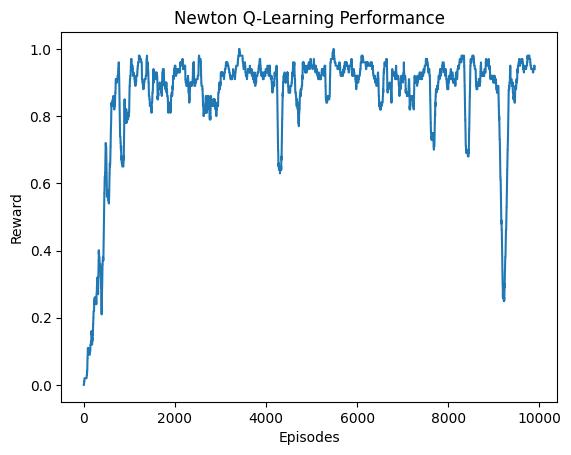

In [25]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
#environment
env = gym.make("FrozenLake-v1", is_slippery=False)
n_states = env.observation_space.n
n_actions = env.action_space.n
#Q-table
Q = np.zeros((n_states, n_actions))
#hyperparameters
episodes = 10000
alpha = 0.3
gamma = 0.99
epsilon = 1.0   #start high
# Newton update
def newton_q_update(Q, s, a, r, s_next):
    td_error = r + gamma * np.max(Q[s_next]) - Q[s,a]    
    grad = td_error    
    #better Hessian approximation
    hessian = abs(td_error) + 1e-5    
    Q[s,a] = Q[s,a] + alpha * grad / hessian
    return Q

#training
rewards = []

for ep in range(episodes):
    state, _ = env.reset()
    done = False
    total_reward = 0

    while not done:
        if np.random.rand() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(Q[state])
        next_state, reward, done, _, _ = env.step(action)
        Q = newton_q_update(Q, state, action, reward, next_state)
        total_reward += reward
        state = next_state

    #decay epsilon AFTER episode
    epsilon = max(0.05, epsilon * 0.995)
    rewards.append(total_reward)
    if ep % 1000 == 0:
        print(f"Episode {ep}, Reward: {total_reward}, Epsilon: {epsilon:.3f}")

#final Q-table
print("\nFinal Q-table:")
print(Q)

#evaluation
success = 0
for _ in range(100):
    state, _ = env.reset()
    done = False   
    while not done:
        action = np.argmax(Q[state])
        state, reward, done, _, _ = env.step(action)   
    success += reward
print("\nSuccess Rate:", success / 100)

#plot
window = 100
smoothed = np.convolve(rewards, np.ones(window)/window, mode='valid')
plt.plot(smoothed)
plt.title("Newton Q-Learning Performance")
plt.xlabel("Episodes")
plt.ylabel("Reward")
plt.show()